# Phase 1 Modality Verification

Use this notebook to inspect a small streamed slice of CARLA Autopilot Multimodal samples, validate a provisional CARLA rig assumption, and only treat LiDAR-to-depth projection as acceptable if the real-frame overlay looks plausible.

This notebook is inspection-only. Reusable logic stays in `src/`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

from src.perception.lidar_conversion import lidar_to_depth, make_validation_figure
from src.perception.modality_verification import (
    estimate_front_camera_intrinsics,
    load_manual_calibration_config,
    resolve_projection_inputs,
    summarize_depth_map,
    summarize_sample,
    take_stream_window,
)

DATASET_NAME = "immanuelpeter/carla-autopilot-multimodal-dataset"
SPLIT = "validation"
TARGET_COUNT = 12
OVERLAY_SAMPLE_INDICES = [0, 5, 11]

DEEP_SCAN_ENABLED = True
DEEP_SCAN_SPLITS = ["validation", "test", "train"]
DEEP_SCAN_MAX_SAMPLES_PER_SPLIT = 250
DEEP_SCAN_TARGET_RUNS = 3
DEEP_SCAN_PER_RUN = 1
DEEP_SCAN_OVERLAY_COUNT = 3

FRONT_WIDTH = 800
FRONT_HEIGHT = 600
FOV_DEGREES = 90.0
CALIBRATION_CONFIG_PATH = ROOT / "configs" / "phase1_provisional_carla_rig.json"

# Manual overrides remain available for emergency debugging only.
MANUAL_INTRINSICS = None
MANUAL_EXTRINSICS = None

DERIVED_INTRINSICS = estimate_front_camera_intrinsics(
    FRONT_WIDTH,
    FRONT_HEIGHT,
    FOV_DEGREES,
)
PROVISIONAL_RIG = load_manual_calibration_config(CALIBRATION_CONFIG_PATH)

print(f"Notebook root: {ROOT}")
print(f"Dataset: {DATASET_NAME} [{SPLIT}] via streaming")
print(f"Inspection budget: {TARGET_COUNT} frames")
print(f"Calibration config: {CALIBRATION_CONFIG_PATH}")
print("Intrinsics are dataset-derived from docs/dataset_card.md; extrinsics come from a provisional CARLA rig assumption.")
print(
    f"Deeper scan: enabled={DEEP_SCAN_ENABLED}, splits={DEEP_SCAN_SPLITS}, "
    f"max_per_split={DEEP_SCAN_MAX_SAMPLES_PER_SPLIT}, target_runs={DEEP_SCAN_TARGET_RUNS}, per_run={DEEP_SCAN_PER_RUN}"
)


Notebook root: D:\carla
Dataset: immanuelpeter/carla-autopilot-multimodal-dataset [validation] via streaming
Inspection budget: 12 frames
Calibration config: D:\carla\configs\phase1_provisional_carla_rig.json
Intrinsics are dataset-derived from docs/dataset_card.md; extrinsics come from a provisional CARLA rig assumption.
Deeper scan: enabled=True, splits=['validation', 'test', 'train'], max_per_split=250, target_runs=3, per_run=1


In [2]:
print("Derived front-camera intrinsics from dataset card spec:")
print(DERIVED_INTRINSICS)
if PROVISIONAL_RIG is not None:
    print("\nProvisional rig provenance:")
    print(PROVISIONAL_RIG["provenance"])
    print("Extrinsics source label:", PROVISIONAL_RIG.get("extrinsics_source_label"))


Derived front-camera intrinsics from dataset card spec:
[[400.   0. 400.]
 [  0. 400. 300.]
 [  0.   0.   1.]]

Provisional rig provenance:
Phase 1 provisional CARLA rig assumption for CARLA Autopilot Multimodal. Front-camera intrinsics are derived from the dataset card (800x600, FOV=90). LiDAR-to-camera extrinsics follow a documented standard CARLA-style front rig and must be validated visually before downstream use.
Extrinsics source label: assumed rig (documented CARLA provisional front rig)


In [3]:
try:
    from datasets import load_dataset
except ImportError as exc:
    raise ImportError(
        "Install the datasets package before running this notebook: pip install -e '.[dev,viz]'"
    ) from exc

streamed_dataset = load_dataset(DATASET_NAME, split=SPLIT, streaming=True)
print("Streaming dataset handle created.")
print("No full local download should happen here; frames are fetched on demand.")


d:\carla\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Streaming dataset handle created.
No full local download should happen here; frames are fetched on demand.


In [4]:
samples = take_stream_window(streamed_dataset, target_count=TARGET_COUNT)
summaries = [summarize_sample(sample) for sample in samples]
unique_runs = sorted({sample.get("run_id") for sample in samples})

for index, summary in enumerate(summaries, start=1):
    print(f"\nSample {index}")
    for key in (
        "run_id",
        "frame",
        "timestamp",
        "speed_kmh",
        "image_width",
        "image_height",
        "lidar_points",
        "calibration_keys_present",
    ):
        if key in summary:
            print(f"  {key}: {summary[key]}")

print(f"\nSelected {len(samples)} streamed validation samples for inspection")
print(f"Unique runs in this window: {unique_runs}")
if len(unique_runs) == 1:
    print("Note: this lightweight inspection window currently spans only one run. We need deeper discovery before calling the rig accepted across runs.")



Sample 1
  run_id: run_008
  frame: 0
  timestamp: 2.184818983078003
  speed_kmh: 10.73122501373291
  image_width: 800
  image_height: 600
  lidar_points: 4942
  calibration_keys_present: ['lidar', 'rotation_pitch', 'rotation_roll', 'rotation_yaw']

Sample 2
  run_id: run_008
  frame: 5
  timestamp: 3.807100534439087
  speed_kmh: 6.52715539932251
  image_width: 800
  image_height: 600
  lidar_points: 5105
  calibration_keys_present: ['lidar', 'rotation_pitch', 'rotation_roll', 'rotation_yaw']

Sample 3
  run_id: run_008
  frame: 10
  timestamp: 5.494970798492432
  speed_kmh: 9.8416166305542
  image_width: 800
  image_height: 600
  lidar_points: 5067
  calibration_keys_present: ['lidar', 'rotation_pitch', 'rotation_roll', 'rotation_yaw']

Sample 4
  run_id: run_008
  frame: 15
  timestamp: 7.417807579040527
  speed_kmh: 13.441064834594727
  image_width: 800
  image_height: 600
  lidar_points: 5112
  calibration_keys_present: ['lidar', 'rotation_pitch', 'rotation_roll', 'rotation_yaw']


In [5]:
def show_frame_preview_grid(samples, count=12, image_key="image_front"):
    preview = samples[:count]
    cols = 4
    rows = int(np.ceil(len(preview) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.8 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, sample in zip(axes, preview):
        image = np.asarray(sample[image_key])
        ax.imshow(image)
        ax.set_title(f"{sample.get('run_id')} | frame {sample.get('frame')}")
        ax.axis("off")

    for ax in axes[len(preview):]:
        ax.axis("off")

    return fig


def print_calibration_status_rows(rows):
    for row in rows:
        print(
            " | ".join(
                [
                    f"run={row['run_id']}",
                    f"frame={row['frame']}",
                    f"can_project={row['can_project']}",
                    f"intrinsics={row['intrinsics_source']}",
                    f"extrinsics={row['extrinsics_source']}",
                    f"blocking_reason={row['blocking_reason']}",
                ]
            )
        )


def render_overlay_gallery(samples, resolved_samples, sample_indices):
    valid_indices = [idx for idx in sample_indices if 0 <= idx < len(samples)]
    if not valid_indices:
        raise ValueError("sample_indices did not contain any valid entries")

    fig, axes = plt.subplots(1, len(valid_indices), figsize=(6 * len(valid_indices), 5), constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, valid_indices):
        sample = samples[idx]
        resolved = resolved_samples[idx]
        rgb = np.asarray(sample["image_front"])
        lidar = np.asarray(sample["lidar"], dtype=np.float64)

        if not resolved["can_project"]:
            ax.imshow(rgb)
            ax.set_title(f"{sample.get('run_id')} frame {sample.get('frame')}\nprojection unavailable")
            ax.axis("off")
            continue

        depth_map = lidar_to_depth(
            lidar,
            resolved["intrinsics"],
            resolved["extrinsics"],
            rgb.shape[:2],
        )
        rows, cols_px = np.where(np.isfinite(depth_map))
        depths = depth_map[rows, cols_px]

        ax.imshow(rgb)
        if depths.size:
            ax.scatter(cols_px, rows, c=depths, s=5, cmap="turbo", alpha=0.9, linewidths=0)
        coverage = summarize_depth_map(depth_map)["coverage"]
        ax.set_title(f"{sample.get('run_id')} frame {sample.get('frame')}\ncoverage={coverage:.4f}")
        ax.axis("off")

    return fig


def take_bounded_multirun_window(dataset_name, splits, *, target_runs, per_run, max_samples_per_split):
    selected = []
    run_counts = {}
    split_scan_counts = {}

    for split_name in splits:
        bounded_stream = load_dataset(dataset_name, split=split_name, streaming=True)
        scanned = 0

        for sample in bounded_stream:
            scanned += 1
            run_id = str(sample.get("run_id", "unknown"))
            current = run_counts.get(run_id, 0)

            if len(run_counts) < target_runs or run_id in run_counts:
                if current < per_run:
                    selected.append(sample)
                    run_counts[run_id] = current + 1

            enough_runs = len(run_counts) >= target_runs
            enough_samples = enough_runs and all(count >= per_run for count in run_counts.values())
            if enough_samples or scanned >= max_samples_per_split:
                break

        split_scan_counts[split_name] = scanned

        enough_runs = len(run_counts) >= target_runs
        enough_samples = enough_runs and all(count >= per_run for count in run_counts.values())
        if enough_samples:
            break

    return selected, run_counts, split_scan_counts


In [6]:
resolved_samples = [
    resolve_projection_inputs(
        sample,
        fov_degrees=FOV_DEGREES,
        manual_intrinsics=MANUAL_INTRINSICS,
        manual_extrinsics=MANUAL_EXTRINSICS,
        manual_calibration=PROVISIONAL_RIG,
    )
    for sample in samples
]

calibration_rows = []
for sample, resolved in zip(samples, resolved_samples):
    calibration_rows.append(
        {
            "run_id": sample.get("run_id"),
            "frame": sample.get("frame"),
            "can_project": resolved["can_project"],
            "intrinsics_source": resolved["intrinsics_source"],
            "extrinsics_source": resolved["extrinsics_source"],
            "blocking_reason": resolved["blocking_reason"],
            "calibration_fields": sorted(resolved["calibration_fields"].keys()),
        }
    )

print("Calibration summary across streamed samples:")
print_calibration_status_rows(calibration_rows)

print("\nInterpretation:")
print("- intrinsics should read as dataset-derived")
print("- extrinsics should read as assumed rig")
print("- any acceptable overlay/depth result is validating the provisional rig, not proving the dataset published exact calibration")


Calibration summary across streamed samples:
run=run_008 | frame=0 | can_project=True | intrinsics=dataset-derived (image shape + FOV=90.0) | extrinsics=assumed rig (documented CARLA provisional front rig) | blocking_reason=None
run=run_008 | frame=5 | can_project=True | intrinsics=dataset-derived (image shape + FOV=90.0) | extrinsics=assumed rig (documented CARLA provisional front rig) | blocking_reason=None
run=run_008 | frame=10 | can_project=True | intrinsics=dataset-derived (image shape + FOV=90.0) | extrinsics=assumed rig (documented CARLA provisional front rig) | blocking_reason=None
run=run_008 | frame=15 | can_project=True | intrinsics=dataset-derived (image shape + FOV=90.0) | extrinsics=assumed rig (documented CARLA provisional front rig) | blocking_reason=None
run=run_008 | frame=20 | can_project=True | intrinsics=dataset-derived (image shape + FOV=90.0) | extrinsics=assumed rig (documented CARLA provisional front rig) | blocking_reason=None
run=run_008 | frame=25 | can_pro

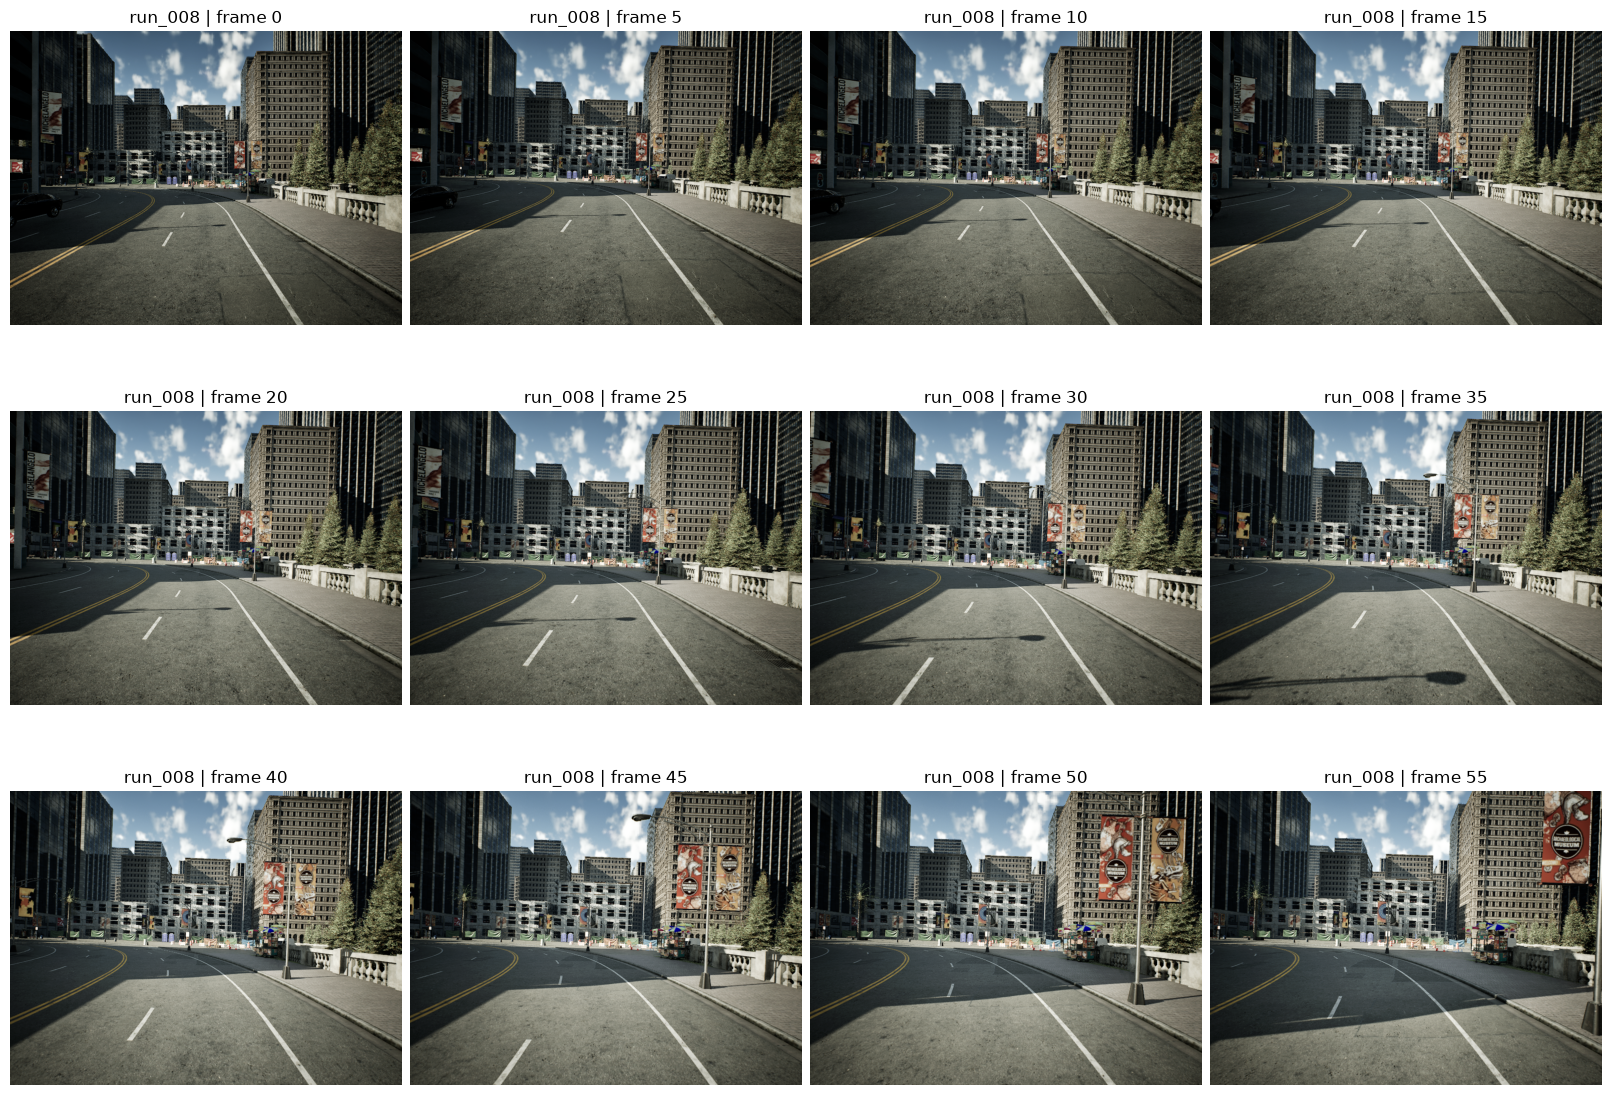

In [7]:
preview_fig = show_frame_preview_grid(samples)
display(preview_fig)
plt.close(preview_fig)


Projection status: projection enabled via dataset-derived (image shape + FOV=90.0) + assumed rig (documented CARLA provisional front rig)
Intrinsics source: dataset-derived (image shape + FOV=90.0)
Extrinsics source: assumed rig (documented CARLA provisional front rig)


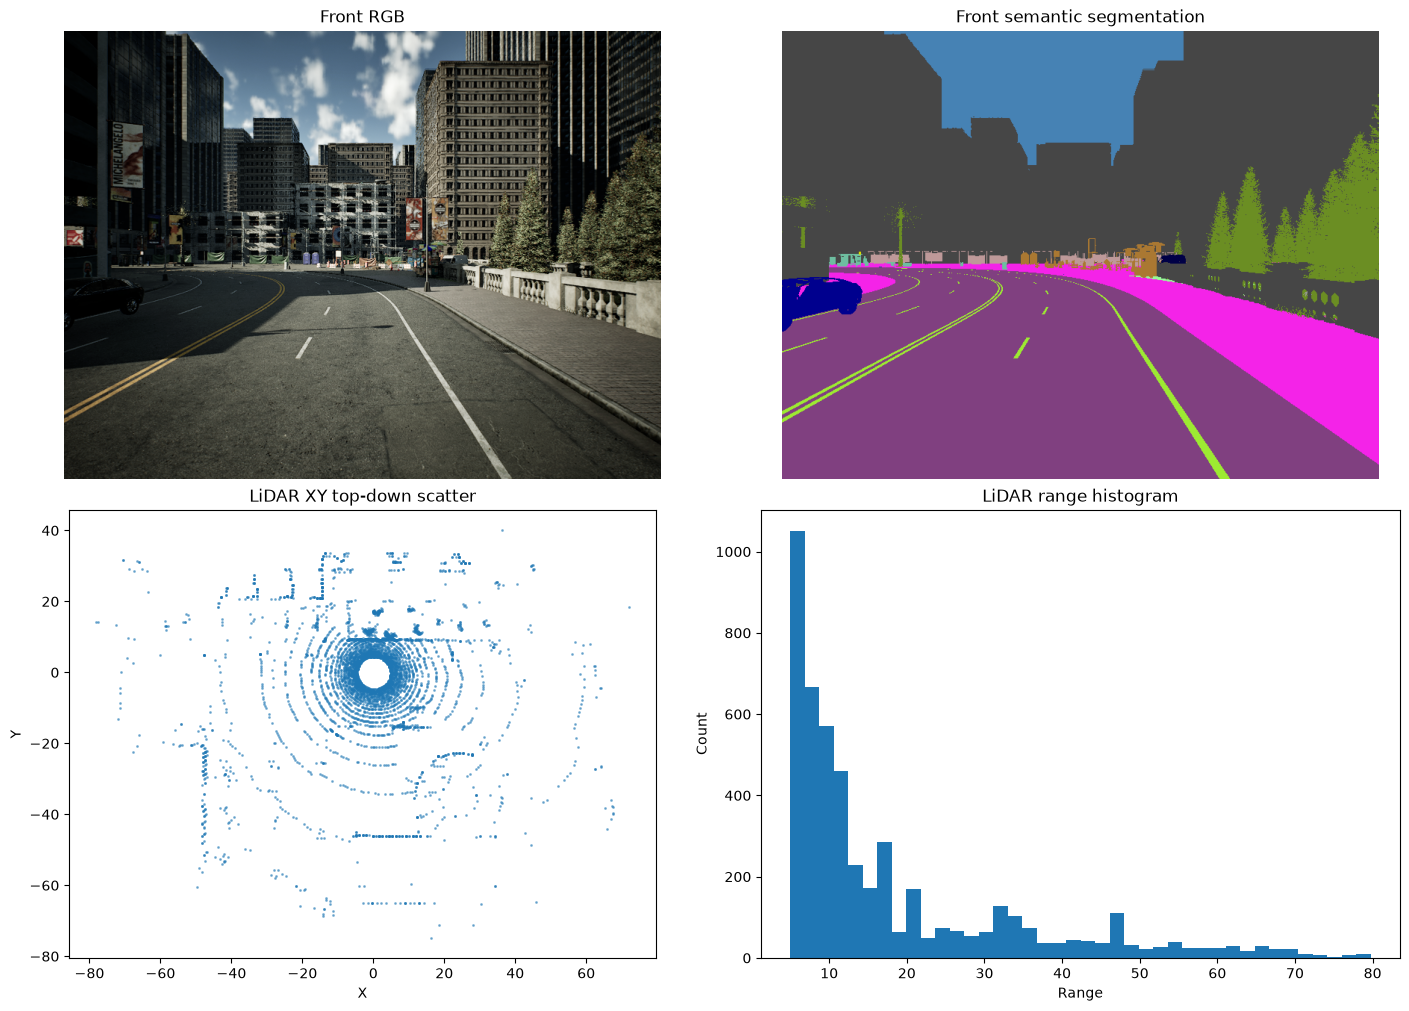

In [8]:
sample_index = 0
sample = samples[sample_index]
resolved = resolved_samples[sample_index]

rgb = np.asarray(sample["image_front"])
seg = np.asarray(sample["seg_front"])
lidar = np.asarray(sample["lidar"], dtype=np.float64)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

axes[0, 0].imshow(rgb)
axes[0, 0].set_title("Front RGB")
axes[0, 0].axis("off")

axes[0, 1].imshow(seg, cmap="tab20")
axes[0, 1].set_title("Front semantic segmentation")
axes[0, 1].axis("off")

axes[1, 0].scatter(lidar[:, 0], lidar[:, 1], s=1.2, alpha=0.45)
axes[1, 0].set_title("LiDAR XY top-down scatter")
axes[1, 0].set_xlabel("X")
axes[1, 0].set_ylabel("Y")
axes[1, 0].set_aspect("equal", adjustable="box")

ranges = np.linalg.norm(lidar[:, :3], axis=1)
axes[1, 1].hist(ranges, bins=40)
axes[1, 1].set_title("LiDAR range histogram")
axes[1, 1].set_xlabel("Range")
axes[1, 1].set_ylabel("Count")

print(f"Projection status: {resolved['status']}")
print(f"Intrinsics source: {resolved['intrinsics_source']}")
print(f"Extrinsics source: {resolved['extrinsics_source']}")
if resolved["blocking_reason"] is not None:
    print(f"Blocking reason: {resolved['blocking_reason']}")

display(fig)
plt.close(fig)


Depth coverage: 0.0017
Depth min/max/mean: 3.570 / 70.651 / 16.045
Overlay/depth below are for rig validation on real streamed frames.


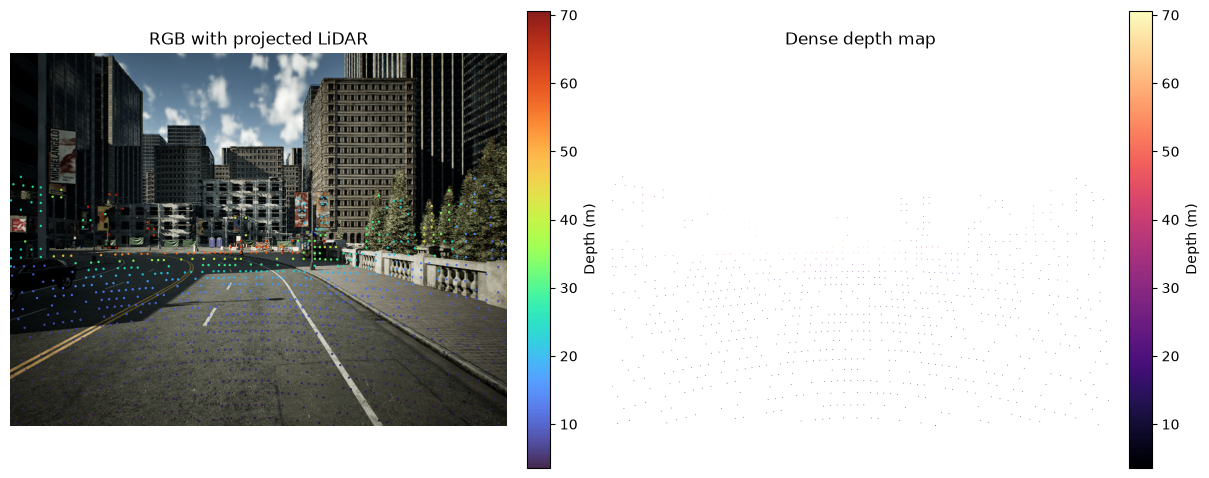

In [9]:
if resolved["can_project"]:
    depth_map = lidar_to_depth(
        lidar,
        resolved["intrinsics"],
        resolved["extrinsics"],
        rgb.shape[:2],
    )
    depth_stats = summarize_depth_map(depth_map)
    print(f"Depth coverage: {depth_stats['coverage']:.4f}")
    print(
        f"Depth min/max/mean: {depth_stats['min_depth']:.3f} / {depth_stats['max_depth']:.3f} / {depth_stats['mean_depth']:.3f}"
    )
    print("Overlay/depth below are for rig validation on real streamed frames.")
    overlay_fig, axes = make_validation_figure(
        rgb,
        lidar,
        resolved["intrinsics"],
        resolved["extrinsics"],
        depth_map=depth_map,
    )
    display(overlay_fig)
    plt.close(overlay_fig)
else:
    print("Projection validation skipped because LiDAR-to-camera extrinsics are unavailable.")


Rendering overlay gallery for sample indices: [0, 5, 11]


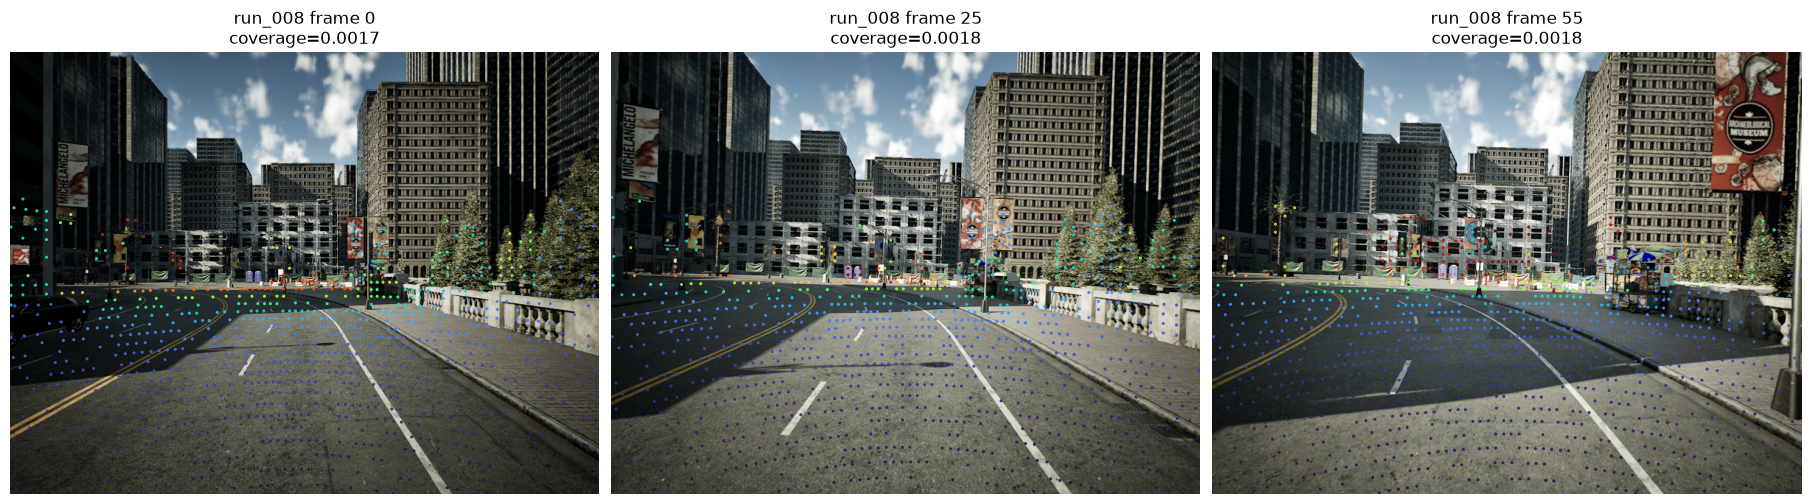

All rendered overlays above are still from one run. They help validate temporal stability, but not cross-run acceptance yet.


In [10]:
print(f"Rendering overlay gallery for sample indices: {OVERLAY_SAMPLE_INDICES}")
gallery_fig = render_overlay_gallery(samples, resolved_samples, OVERLAY_SAMPLE_INDICES)
display(gallery_fig)
plt.close(gallery_fig)
if len(unique_runs) == 1:
    print("All rendered overlays above are still from one run. They help validate temporal stability, but not cross-run acceptance yet.")


In [11]:
deeper_samples = []
deeper_run_counts = {}
deeper_split_scan_counts = {}
deeper_unique_runs = []
deeper_resolved_samples = []

if DEEP_SCAN_ENABLED:
    deeper_samples, deeper_run_counts, deeper_split_scan_counts = take_bounded_multirun_window(
        DATASET_NAME,
        DEEP_SCAN_SPLITS,
        target_runs=DEEP_SCAN_TARGET_RUNS,
        per_run=DEEP_SCAN_PER_RUN,
        max_samples_per_split=DEEP_SCAN_MAX_SAMPLES_PER_SPLIT,
    )
    deeper_unique_runs = sorted(deeper_run_counts.keys())
    total_scanned = sum(deeper_split_scan_counts.values())
    print(f"Bounded deeper scan inspected {total_scanned} streamed samples across splits.")
    print(f"Per-split scan counts: {deeper_split_scan_counts}")
    print(f"Discovered run counts: {deeper_run_counts}")
    print(f"Unique runs discovered: {deeper_unique_runs}")

    if deeper_samples:
        deeper_resolved_samples = [
            resolve_projection_inputs(
                sample,
                fov_degrees=FOV_DEGREES,
                manual_intrinsics=MANUAL_INTRINSICS,
                manual_extrinsics=MANUAL_EXTRINSICS,
                manual_calibration=PROVISIONAL_RIG,
            )
            for sample in deeper_samples
        ]
    else:
        print("No deeper-scan samples were collected within the cap.")

    if len(deeper_unique_runs) >= DEEP_SCAN_TARGET_RUNS:
        print("Deeper scan reached the target number of runs. If the overlay gallery looks plausible, the rig is no longer just a one-run pass.")
    else:
        print("The bounded scan still did not reach the target number of runs. If the overlays look good, the rig is accepted for the current streamed coverage but broader cross-run acceptance is still pending.")
else:
    print("Deeper scan is disabled.")


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/immanuelpeter/carla-autopilot-multimodal-dataset/resolve/e3ec78df1c561370c25364fa1b1daed03af754aa/data/validation-00001-of-00072.parquet
Retrying in 1s [Retry 1/5].
'_ssl.c:993: The handshake operation timed out' thrown while requesting GET https://huggingface.co/datasets/immanuelpeter/carla-autopilot-multimodal-dataset/resolve/e3ec78df1c561370c25364fa1b1daed03af754aa/data/test-00000-of-00064.parquet
Retrying in 1s [Retry 1/5].
'_ssl.c:993: The handshake operation timed out' thrown while requesting GET https://huggingface.co/datasets/immanuelpeter/carla-autopilot-multimodal-dataset/resolve/e3ec78df1c561370c25364fa1b1daed03af754aa/data/test-00000-of-00064.parquet
Retrying in 2s [Retry 2/5].
'_ssl.c:993: The handshake operation timed out' thrown while requesting GET https://huggingface.co/datasets/immanuelpeter/carla-autopilot-multimodal-dataset/resolve/e3ec78df1c561370c25364fa1b1daed03af754aa/data

Bounded deeper scan inspected 501 streamed samples across splits.
Per-split scan counts: {'validation': 250, 'test': 250, 'train': 1}
Discovered run counts: {'run_008': 1, 'run_001': 1, 'run_020': 1}
Unique runs discovered: ['run_001', 'run_008', 'run_020']
Deeper scan reached the target number of runs. If the overlay gallery looks plausible, the rig is no longer just a one-run pass.


Rendering bounded deeper-scan overlay gallery:


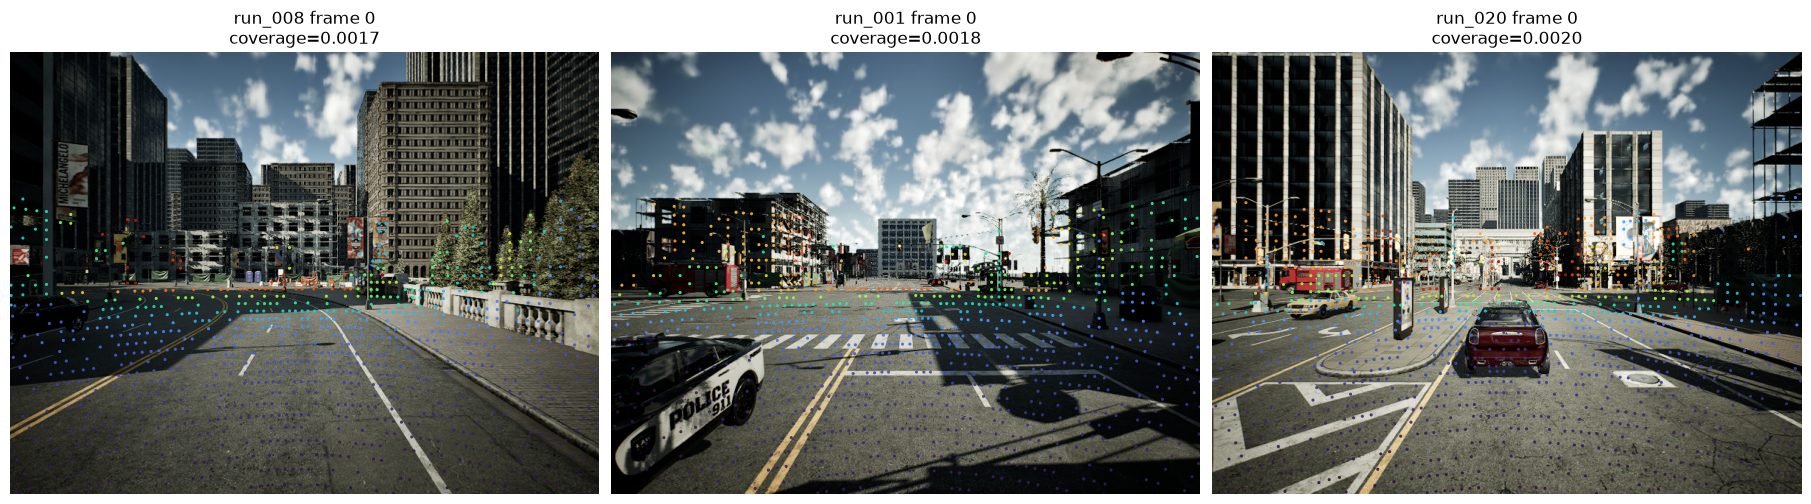

In [12]:
if deeper_samples:
    print("Rendering bounded deeper-scan overlay gallery:")
    deep_overlay_indices = list(range(min(DEEP_SCAN_OVERLAY_COUNT, len(deeper_samples))))
    deep_gallery_fig = render_overlay_gallery(deeper_samples, deeper_resolved_samples, deep_overlay_indices)
    display(deep_gallery_fig)
    plt.close(deep_gallery_fig)
else:
    print("No deeper-scan overlay gallery to render.")


In [13]:
inspection_log = []

for sample, resolved in zip(samples, resolved_samples):
    lidar = np.asarray(sample["lidar"], dtype=np.float64)
    row = {
        "run_id": sample.get("run_id"),
        "frame": sample.get("frame"),
        "timestamp": sample.get("timestamp"),
        "can_project": resolved["can_project"],
        "projection_status": resolved["status"],
        "intrinsics_source": resolved["intrinsics_source"],
        "extrinsics_source": resolved["extrinsics_source"],
        "blocking_reason": resolved["blocking_reason"],
        "lidar_points": int(lidar.shape[0]),
    }

    if resolved["can_project"]:
        rgb = np.asarray(sample["image_front"])
        depth_map = lidar_to_depth(
            lidar,
            resolved["intrinsics"],
            resolved["extrinsics"],
            rgb.shape[:2],
        )
        row["depth_coverage"] = summarize_depth_map(depth_map)["coverage"]

    inspection_log.append(row)

for row in inspection_log:
    print(row)

print("\nManual review checklist:")
print("- RGB frames look sensible")
print("- segmentation looks aligned with RGB")
print("- LiDAR XY scatter is plausible")
print("- overlay points land on plausible scene geometry")
print("- no obvious global flip, large shift, or severe scale mismatch")
print("- if deeper scan reaches multiple runs and the overlays stay plausible, accept the rig beyond the one-run pass")
print("- if deeper scan still misses additional runs, the code is not necessarily wrong; the streamed ordering may still be long-run contiguous")


{'run_id': 'run_008', 'frame': 0, 'timestamp': 2.184818983078003, 'can_project': True, 'projection_status': 'projection enabled via dataset-derived (image shape + FOV=90.0) + assumed rig (documented CARLA provisional front rig)', 'intrinsics_source': 'dataset-derived (image shape + FOV=90.0)', 'extrinsics_source': 'assumed rig (documented CARLA provisional front rig)', 'blocking_reason': None, 'lidar_points': 4942, 'depth_coverage': 0.0017291666666666666}
{'run_id': 'run_008', 'frame': 5, 'timestamp': 3.807100534439087, 'can_project': True, 'projection_status': 'projection enabled via dataset-derived (image shape + FOV=90.0) + assumed rig (documented CARLA provisional front rig)', 'intrinsics_source': 'dataset-derived (image shape + FOV=90.0)', 'extrinsics_source': 'assumed rig (documented CARLA provisional front rig)', 'blocking_reason': None, 'lidar_points': 5105, 'depth_coverage': 0.0018375}
{'run_id': 'run_008', 'frame': 10, 'timestamp': 5.494970798492432, 'can_project': True, 'pro